In [1]:
import os
import numpy as np
import xarray as xr
import geopandas as gpd

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

In [2]:
GEV_dir = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','1_GEV','corrected')
MEV_dir = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','2_MEV','corrected')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [3]:
if os.path.exists(veneto_dir):
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_clear.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

In [4]:
lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'
Tr = [5,  10,  20,  50, 100, 200]

In [5]:
DATA = xr.open_dataset(os.path.join(GEV_dir,'ITALY_DOWN_IMERG_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_IM, lat2d_IM = np.meshgrid(DATA.lon, DATA.lat)
GEV_IM = DATA.GEVs.values

DATA = xr.open_dataset(os.path.join(GEV_dir,'ITALY_DOWN_CMORPH_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_CM, lat2d_CM = np.meshgrid(DATA.lon, DATA.lat)
GEV_CM = DATA.GEVs.values

DATA = xr.open_dataset(os.path.join(GEV_dir,'ITALY_DOWN_MSWEP_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_MS, lat2d_MS = np.meshgrid(DATA.lon, DATA.lat)
GEV_MS = DATA.GEVs.values

DATA = xr.open_dataset(os.path.join(GEV_dir,'ITALY_DOWN_ERA5_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_ER, lat2d_ER = np.meshgrid(DATA.lon, DATA.lat)
GEV_ER = DATA.GEVs.values

DATA = xr.open_dataset(os.path.join(GEV_dir,'ITALY_DOWN_GSMaP_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_GS, lat2d_GS = np.meshgrid(DATA.lon, DATA.lat)
GEV_GS = DATA.GEVs.values

DATA = xr.open_dataset(os.path.join(GEV_dir,'ITALY_DOWN_CHIRPS_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_CH, lat2d_CH = np.meshgrid(DATA.lon, DATA.lat)
GEV_CH = DATA.GEVs.values

Return Time: 50 years
Export figure to: ../../figures/ALL/Quantiles_ALL_GEV_raw_50yrs_corrected.png


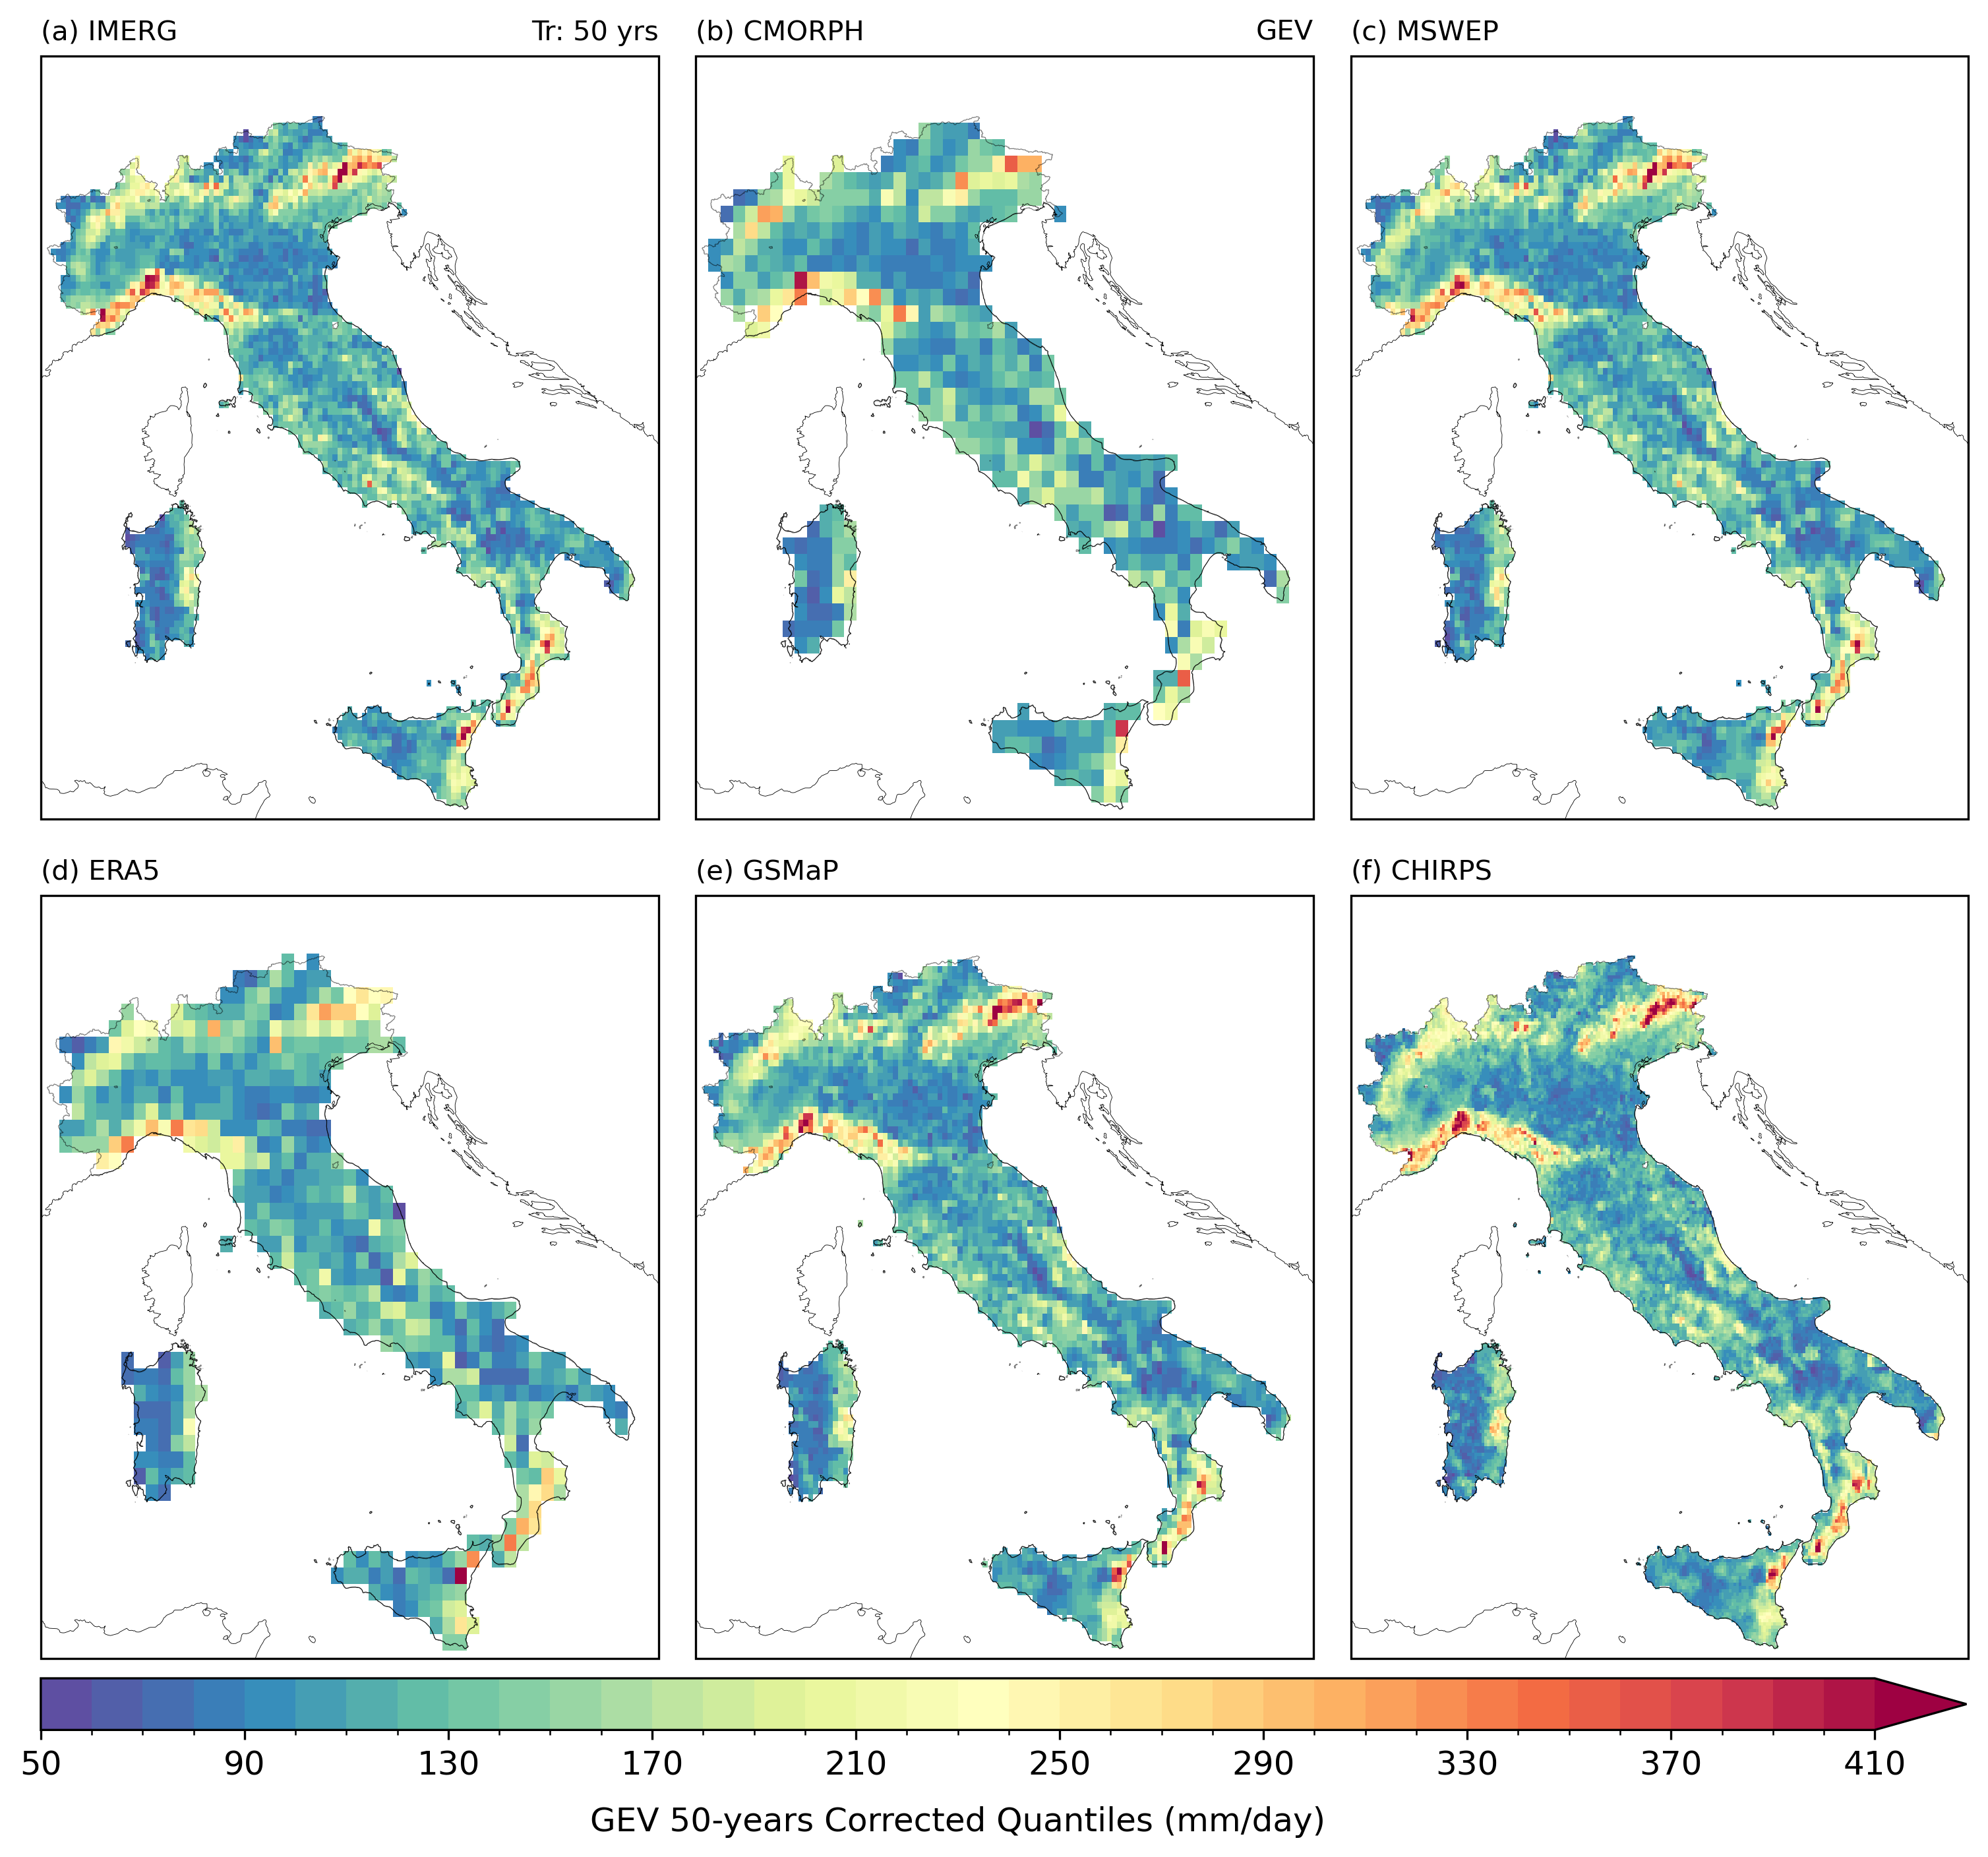

In [6]:
pos = 3
print(f'Return Time: {Tr[pos]} years')

Mev_levels = np.arange(50, 420, 10)
fonttitle = 10

Mev_cmap = plt.cm.Spectral_r
Mev_diff = plt.cm.coolwarm_r

norm = mcolors.BoundaryNorm(boundaries=Mev_levels, ncolors=Mev_cmap.N, extend='max')
# norm = None

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(11, 9), dpi=300)
gs = gridspec.GridSpec(2, 3)

axes = []
for nraw in range(2):
    for ncol in range(3):
        ax = fig.add_subplot(gs[nraw, ncol], projection=proj)
        # DEM.plot(facecolor='None', edgecolor='k', ax=ax, linewidth=0.1, zorder=15, alpha=0.6)
        ITALY.plot(facecolor='None', edgecolor='k', ax=ax, linewidth=0.3, zorder=21, alpha=0.5)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
        ax.coastlines(linewidth=0.2)
        axes.append(ax)

a1 = axes[0].pcolormesh(lon2d_IM, lat2d_IM, GEV_IM[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[0], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[1].pcolormesh(lon2d_CM, lat2d_CM, GEV_CM[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[1], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[2].pcolormesh(lon2d_MS, lat2d_MS, GEV_MS[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[2], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[3].pcolormesh(lon2d_ER, lat2d_ER, GEV_ER[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[3], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[4].pcolormesh(lon2d_GS, lat2d_GS, GEV_GS[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[4], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[5].pcolormesh(lon2d_CH, lat2d_CH, GEV_CH[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[5], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

axes[0].set_title('(a) IMERG', fontsize=fonttitle, loc='left')
axes[0].set_title(f'Tr: {Tr[pos]} yrs', fontsize=fonttitle, loc='right')
# axes[0].set_title(f'Point scale', fontsize=fonttitle, loc='right')
axes[1].set_title('(b) CMORPH', fontsize=fonttitle, loc='left')
axes[1].set_title(f'GEV', fontsize=fonttitle, loc='right')
# axes[1].set_title(f'Point scale', fontsize=fonttitle, loc='right')
axes[2].set_title('(c) MSWEP', fontsize=fonttitle, loc='left')
# axes[2].set_title(f'Point scale', fontsize=fonttitle, loc='right')
axes[3].set_title('(d) ERA5', fontsize=fonttitle, loc='left')
# axes[3].set_title(f'Point scale', fontsize=fonttitle, loc='right')
axes[4].set_title('(e) GSMaP', fontsize=fonttitle, loc='left')
# axes[4].set_title(f'Point scale', fontsize=fonttitle, loc='right')
axes[5].set_title('(f) CHIRPS', fontsize=fonttitle, loc='left')
# axes[5].set_title(f'Point scale', fontsize=fonttitle, loc='right')

cbar_ax = fig.add_axes([0.057, 0.01, 0.885, 0.029]) # Horizontal
cbar = fig.colorbar(a1, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=12)
cbar.set_label(f"GEV {Tr[pos]}-years Corrected Quantiles (mm/day)", fontsize=12, labelpad=9)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.01, hspace=0.1)

salida = os.path.join('..','..','figures','ALL',f'Quantiles_ALL_GEV_raw_{Tr[pos]}yrs_corrected.png')
print(f'Export figure to: {salida}')
plt.savefig(salida,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)


In [7]:
DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_IMERG_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_IM, lat2d_IM = np.meshgrid(DATA.lon, DATA.lat)
MEV_IM = DATA.Mev_s.values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_CMORPH_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_CM, lat2d_CM = np.meshgrid(DATA.lon, DATA.lat)
MEV_CM = DATA.Mev_s.values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_MSWEP_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_MS, lat2d_MS = np.meshgrid(DATA.lon, DATA.lat)
MEV_MS = DATA.Mev_s.values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_ERA5_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_ER, lat2d_ER = np.meshgrid(DATA.lon, DATA.lat)
MEV_ER = DATA.Mev_s.values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_GSMaP_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_GS, lat2d_GS = np.meshgrid(DATA.lon, DATA.lat)
MEV_GS = DATA.Mev_s.values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_CHIRPS_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_CH, lat2d_CH = np.meshgrid(DATA.lon, DATA.lat)
MEV_CH = DATA.Mev_s.values

Return Time: 50 years
Export figure to: ../../figures/ALL/Quantiles_ALL_MEV_raw_50yrs_corrected.png


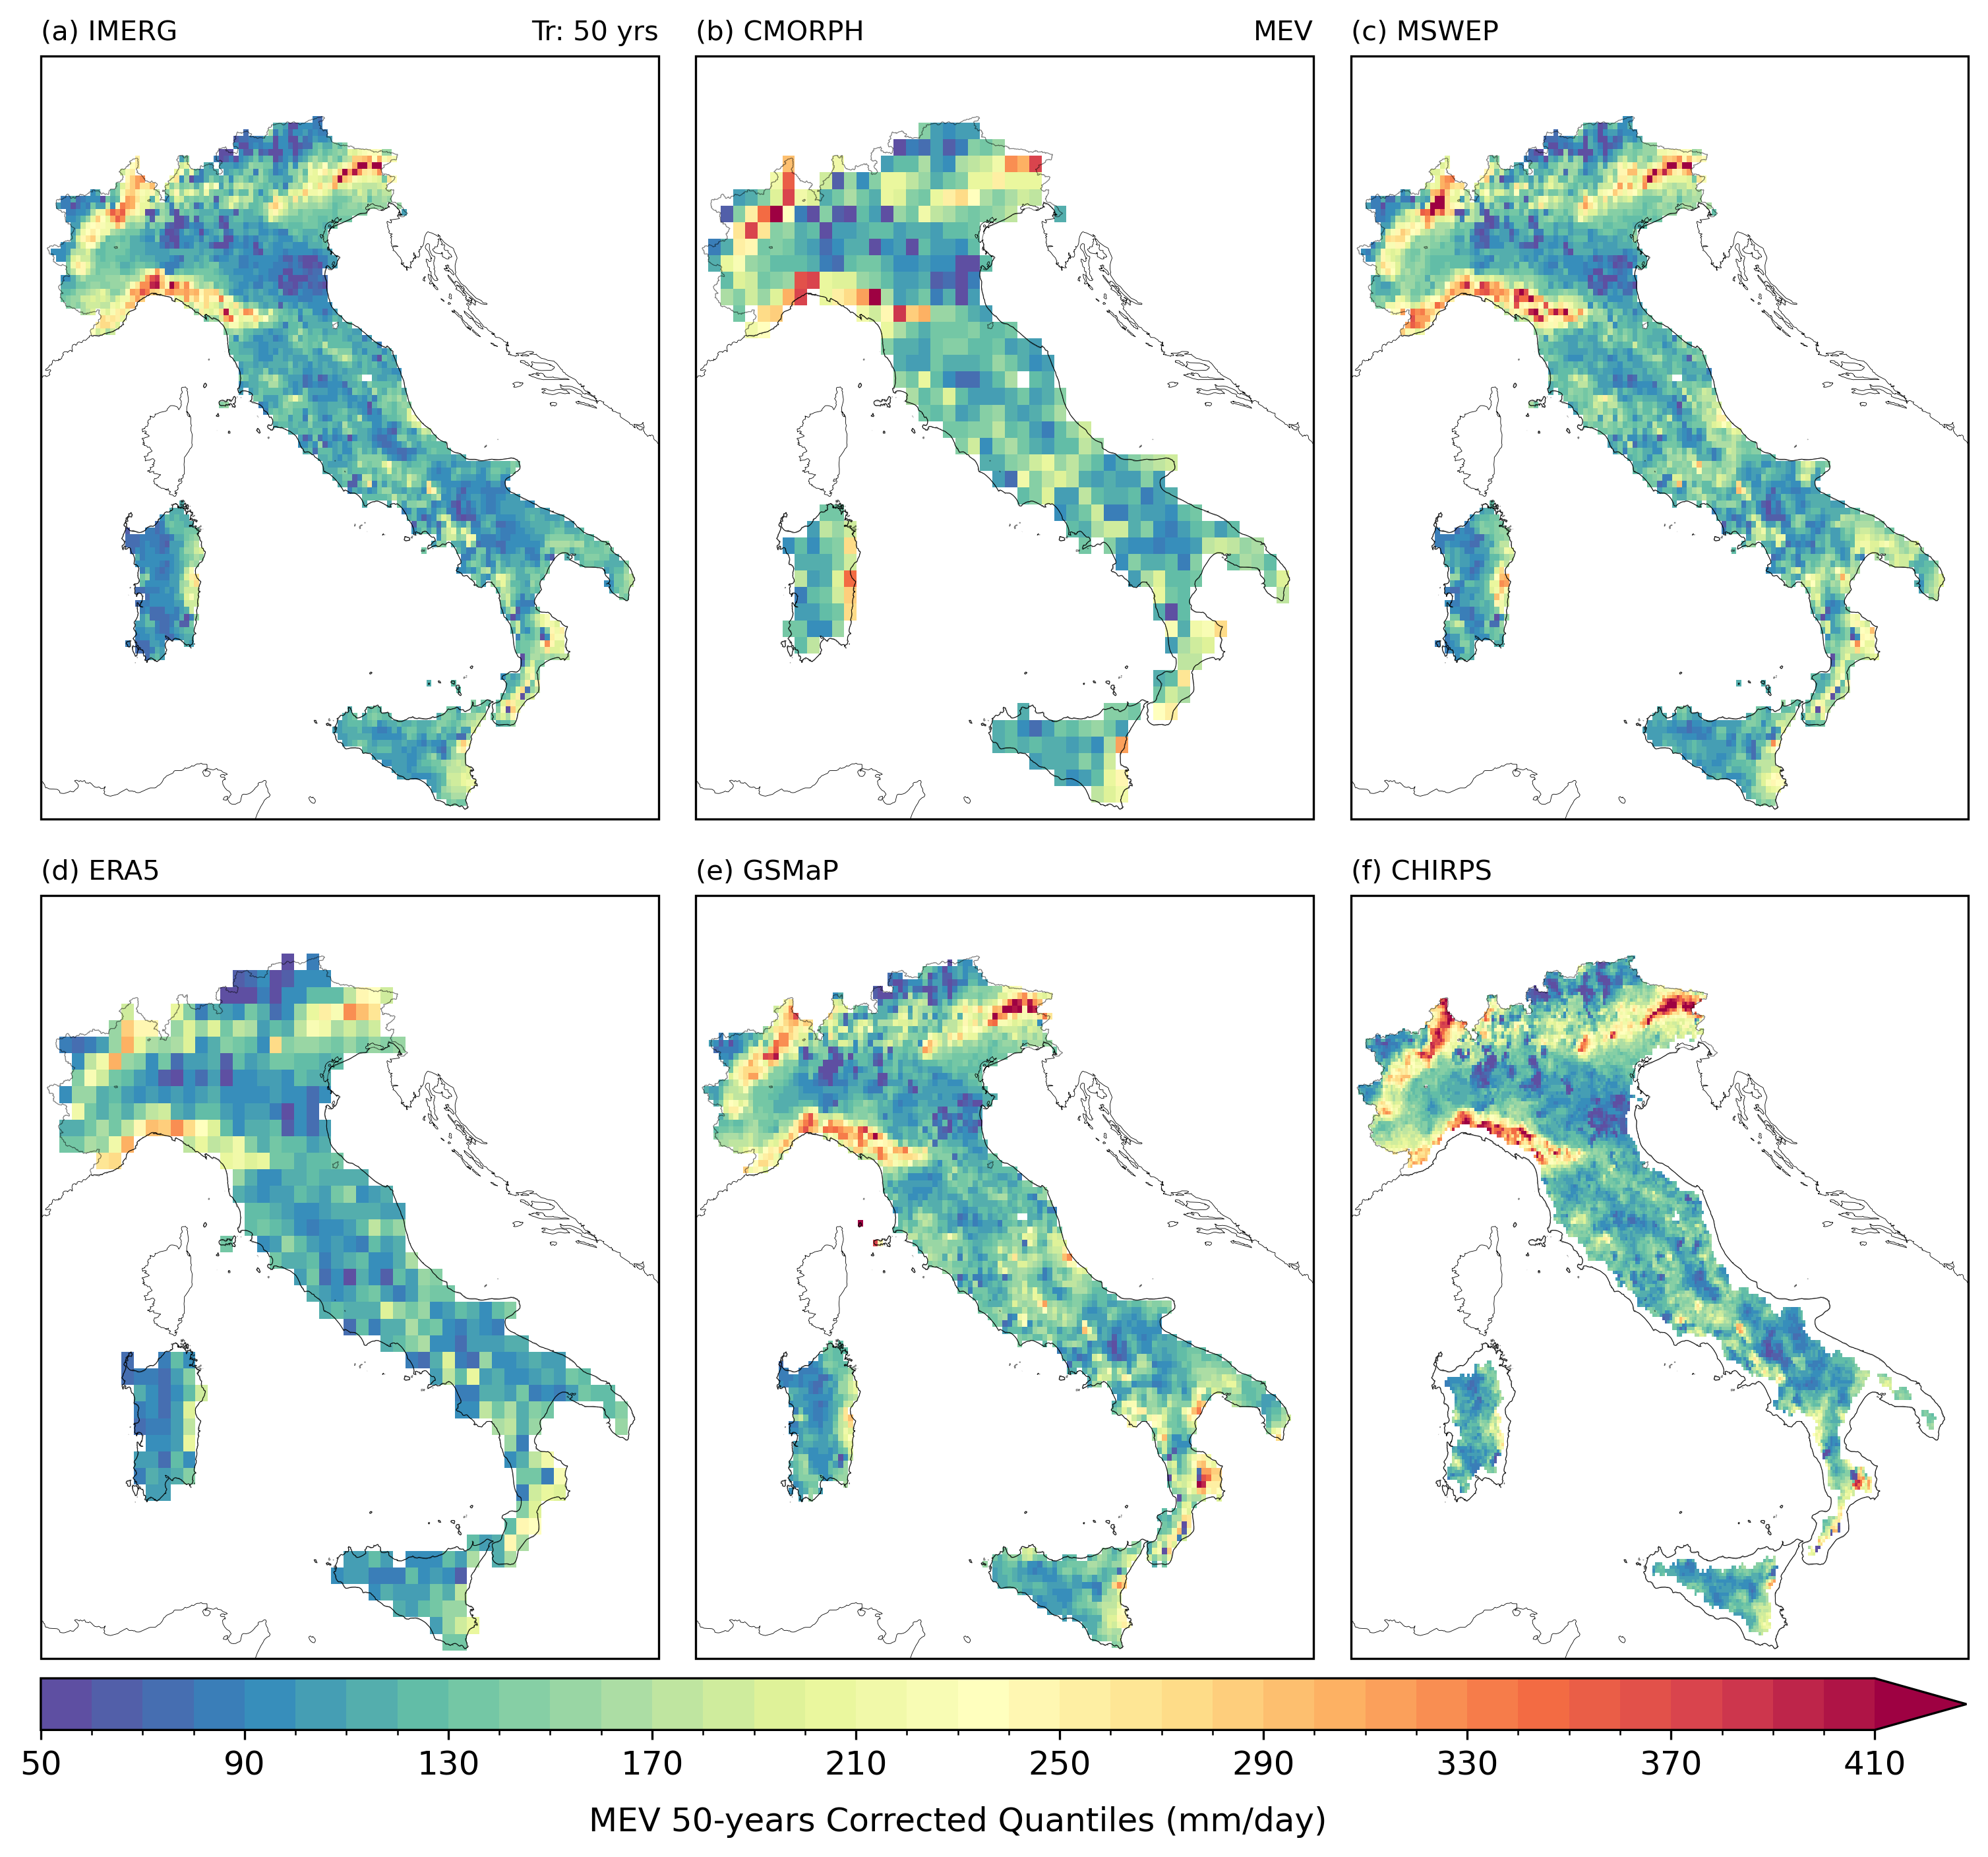

In [9]:
pos = 3
print(f'Return Time: {Tr[pos]} years')

Mev_levels = np.arange(50, 420, 10)
fonttitle = 10

Mev_cmap = plt.cm.Spectral_r
Mev_diff = plt.cm.coolwarm_r

norm = mcolors.BoundaryNorm(boundaries=Mev_levels, ncolors=Mev_cmap.N, extend='max')
# norm = None

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(11, 9), dpi=300)
gs = gridspec.GridSpec(2, 3)

axes = []
for nraw in range(2):
    for ncol in range(3):
        ax = fig.add_subplot(gs[nraw, ncol], projection=proj)
        # DEM.plot(facecolor='None', edgecolor='k', ax=ax, linewidth=0.1, zorder=15, alpha=0.6)
        ITALY.plot(facecolor='None', edgecolor='k', ax=ax, linewidth=0.3, zorder=21, alpha=0.5)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
        ax.coastlines(linewidth=0.2)
        axes.append(ax)

a1 = axes[0].pcolormesh(lon2d_IM, lat2d_IM, MEV_IM[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[0], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[1].pcolormesh(lon2d_CM, lat2d_CM, MEV_CM[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[1], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[2].pcolormesh(lon2d_MS, lat2d_MS, MEV_MS[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[2], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[3].pcolormesh(lon2d_ER, lat2d_ER, MEV_ER[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[3], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[4].pcolormesh(lon2d_GS, lat2d_GS, MEV_GS[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[4], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[5].pcolormesh(lon2d_CH, lat2d_CH, MEV_CH[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[5], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

axes[0].set_title('(a) IMERG', fontsize=fonttitle, loc='left')
axes[0].set_title(f'Tr: {Tr[pos]} yrs', fontsize=fonttitle, loc='right')
# axes[0].set_title(f'Point scale', fontsize=fonttitle, loc='right')
axes[1].set_title('(b) CMORPH', fontsize=fonttitle, loc='left')
axes[1].set_title(f'MEV', fontsize=fonttitle, loc='right')
# axes[1].set_title(f'Point scale', fontsize=fonttitle, loc='right')
axes[2].set_title('(c) MSWEP', fontsize=fonttitle, loc='left')
# axes[2].set_title(f'Point scale', fontsize=fonttitle, loc='right')
axes[3].set_title('(d) ERA5', fontsize=fonttitle, loc='left')
# axes[3].set_title(f'Point scale', fontsize=fonttitle, loc='right')
axes[4].set_title('(e) GSMaP', fontsize=fonttitle, loc='left')
# axes[4].set_title(f'Point scale', fontsize=fonttitle, loc='right')
axes[5].set_title('(f) CHIRPS', fontsize=fonttitle, loc='left')
# axes[5].set_title(f'Point scale', fontsize=fonttitle, loc='right')

cbar_ax = fig.add_axes([0.057, 0.01, 0.885, 0.029]) # Horizontal
cbar = fig.colorbar(a1, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=12)
cbar.set_label(f"MEV {Tr[pos]}-years Corrected Quantiles (mm/day)", fontsize=12, labelpad=9)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.01, hspace=0.1)

salida = os.path.join('..','..','figures','ALL',f'Quantiles_ALL_MEV_raw_{Tr[pos]}yrs_corrected.png')
print(f'Export figure to: {salida}')
plt.savefig(salida,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)
